In [2]:
!pip install -U transformers peft datasets bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [1]:
from huggingface_hub import notebook_login
notebook_login()  # Uncomment if Gemma access requires your HF token


In [5]:
import zipfile
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')


zip_path = "/content/drive/MyDrive/NLP_Safety_Aware_GRP_5/final_gemma_scorer_itr_2.zip"
extract_dir = "./loaded_best_model"

# 3. Extract the model
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Model successfully extracted to {extract_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model successfully extracted to ./loaded_best_model


In [6]:
import torch
import gc
import torch.nn as nn
import numpy as np
from datasets import load_dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    EvalPrediction
)
from peft import PeftModel, TaskType, prepare_model_for_kbit_training
from torch.utils.data import DataLoader

# ==========================================
# 1. Configuration & Base Setup
# ==========================================
MODEL_NAME = "google/gemma-2b"
DATASET_NAME = "toxigen/toxigen-data"
OUTPUT_DIR = "./gemma-toxigen-regression"

# 4-bit Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Setting up Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================================
# 2. Custom Trainer for Regression Loss
# ==========================================
class RegressionTrainer(Trainer):
    def __init__(self, *args, loss_type="mse", **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_type = loss_type

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        # Ensure logits are 1D (batch_size,) to match labels
        logits = outputs.logits.squeeze(-1)

        if self.loss_type == "mse":
            loss_fct = nn.MSELoss()
        elif self.loss_type == "l1":
            loss_fct = nn.L1Loss()
        else:
            loss_fct = nn.MSELoss()

        loss = loss_fct(logits, labels.float())
        return (loss, outputs) if return_outputs else loss

# ==========================================
# 3. Dataset: Continuous Labels & Splits
# ==========================================
print("Loading and Splitting Dataset...")
dataset = load_dataset(DATASET_NAME, name="annotated", split="train")

def format_dataset(example):
    raw_score = float(example.get("toxicity_ai", 1.0))
    normalized_score = (raw_score - 1.0) / 4.0

    return {
        "text": example["text"],
        "labels": normalized_score # <--- FIX: Changed 'label' to 'labels'
    }

dataset = dataset.map(format_dataset, remove_columns=dataset.column_names)
# print("Shrinking dataset for faster testing...")
# dataset = dataset.shuffle(seed=42).select(range(100))

# 80/10/10 Split
train_temp_split = dataset.train_test_split(test_size=0.2, seed=42)
train_data = train_temp_split["train"]
temp_data = train_temp_split["test"]

val_test_split = temp_data.train_test_split(test_size=0.5, seed=42)
val_data = val_test_split["train"]
test_data = val_test_split["test"]

print(f"Dataset splits - Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_val = val_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

# ==========================================
# 4. Regression Metrics
# ==========================================
def compute_metrics(p: EvalPrediction):
    preds = p.predictions.squeeze()
    return {
        "mse": mean_squared_error(p.label_ids, preds),
        "mae": mean_absolute_error(p.label_ids, preds)
    }

# ==========================================
# 5. Hyperparameter Search Function
# ==========================================
def run_hyperparameter_search():
    learning_rates = [7e-5]
    dropouts = [0.1]
    loss_functions = ["mse"]

    best_eval_loss = float("inf")
    best_params = {}
    best_model_dir = ""

    experiment_num = 1

    for lr in learning_rates:
        for dropout in dropouts:
            for loss_fn in loss_functions:
                print(f"\n--- Running Experiment {experiment_num}/8 ---")
                print(f"Params: LR={lr}, Dropout={dropout}, Loss={loss_fn}")

                model = AutoModelForSequenceClassification.from_pretrained(
                    MODEL_NAME, num_labels=1, quantization_config=bnb_config, device_map="auto", dtype=torch.float16
                )
                model.config.pad_token_id = tokenizer.pad_token_id
                model = prepare_model_for_kbit_training(model)

                print("Loading saved adapter layers from Google Drive for continued training...")
                model = PeftModel.from_pretrained(
                    model,
                    extract_dir, # Points to "./loaded_best_model"
                    is_trainable=True
                )
                model.print_trainable_parameters()

                current_output_dir = f"{OUTPUT_DIR}/run_{experiment_num}"

                training_args = TrainingArguments(
                    output_dir=current_output_dir,
                    per_device_train_batch_size=4,
                    per_device_eval_batch_size=4,
                    gradient_accumulation_steps=4,
                    learning_rate=lr,
                    num_train_epochs=1,
                    eval_strategy="steps",
                    eval_steps=50,
                    save_strategy="epoch",
                    logging_steps=50,
                    optim="paged_adamw_8bit",
                    fp16=True,
                    report_to="none"
                )

                trainer = RegressionTrainer(
                    model=model,
                    args=training_args,
                    train_dataset=tokenized_train,
                    eval_dataset=tokenized_val,
                    processing_class=tokenizer,
                    data_collator=data_collator,
                    compute_metrics=compute_metrics,
                    loss_type=loss_fn
                )

                trainer.train()

                current_loss = float("inf")
                for log in reversed(trainer.state.log_history):
                    if "eval_loss" in log:
                        current_loss = log["eval_loss"]
                        break

                print(f"Experiment {experiment_num} Eval Loss: {current_loss:.4f}")

                if current_loss < best_eval_loss:
                    best_eval_loss = current_loss
                    best_params = {"lr": lr, "dropout": dropout, "loss_function": loss_fn}
                    best_model_dir = current_output_dir
                    trainer.save_model(f"{OUTPUT_DIR}/best_model")

                del model
                del trainer
                torch.cuda.empty_cache()
                gc.collect()

                experiment_num += 1

    print("\n=============================================")
    print(f"Hyperparameter Search Complete!")
    print(f"Best Params: {best_params}")
    print(f"Best Eval Loss: {best_eval_loss:.4f}")
    print("=============================================\n")

    return f"{OUTPUT_DIR}/best_model", best_params

# ==========================================
# 6. Final Testing & Inference (PyTorch Loop)
# ==========================================
def evaluate_on_test_set(best_model_path, best_params):
    print("\nLoading Best Model for Final Testing on Holdout Set...")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=1, quantization_config=bnb_config, device_map="auto", dtype=torch.float16
    )
    model.config.pad_token_id = tokenizer.pad_token_id

    from peft import PeftModel
    model = PeftModel.from_pretrained(model, best_model_path)
    model.eval()

    print("Running Final Test Evaluation...")

    # <--- FIX: Updated to expect 'labels' instead of 'label'
    tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    test_dataloader = DataLoader(tokenized_test, batch_size=8, collate_fn=data_collator)

    all_preds = []
    all_labels = []

    for batch in test_dataloader:
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        labels = batch["labels"].to(model.device) # <--- FIX

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)

        all_preds.extend(logits.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    mse = mean_squared_error(all_labels, all_preds)
    mae = mean_absolute_error(all_labels, all_preds)

    print("\n--- Final Test Set Results ---")
    print(f"Test Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Test Mean Squared Error (MSE): {mse:.4f}")

    sample_text = "I think you are incredibly stupid and foolish."
    inputs = tokenizer(sample_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        score = model(**inputs).logits.item()

    print("\n--- Inference Demo ---")
    print(f"Text: {sample_text}")
    print(f"Predicted Toxicity Score: {score:.4f}")

# ==========================================
# 7. Execution Pipeline
# ==========================================
if __name__ == "__main__":
    best_model_path, best_params = run_hyperparameter_search()
    evaluate_on_test_set(best_model_path, best_params)

Setting up Tokenizer...
Loading and Splitting Dataset...
Dataset splits - Train: 7168, Val: 896, Test: 896

--- Running Experiment 1/8 ---
Params: LR=7e-05, Dropout=0.1, Loss=mse


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] GemmaForSequenceClassification LOAD REPORT from: google/gemma-2b
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading saved adapter layers from Google Drive for continued training...
trainable params: 3,688,448 || all params: 2,509,862,912 || trainable%: 0.1470


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Experiment 1 Eval Loss: 0.0338

Hyperparameter Search Complete!
Best Params: {'lr': 7e-05, 'dropout': 0.1, 'loss_function': 'mse'}
Best Eval Loss: 0.0338


Loading Best Model for Final Testing on Holdout Set...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] GemmaForSequenceClassification LOAD REPORT from: google/gemma-2b
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Final Test Evaluation...

--- Final Test Set Results ---
Test Mean Absolute Error (MAE): 0.1541
Test Mean Squared Error (MSE): 0.0541

--- Inference Demo ---
Text: I think you are incredibly stupid and foolish.
Predicted Toxicity Score: 0.6230


In [7]:
import shutil
import os
from google.colab import files

# Your best model and tokenizer were automatically saved here during Cell 1
best_model_folder = "./gemma-toxigen-regression/best_model"

print(f"Locating saved files at {best_model_folder}...")

if os.path.exists(best_model_folder):
    print("Files found! Zipping the directory...")

    # Zip the folder directly
    zip_filename = "final_gemma_scorer"
    shutil.make_archive(zip_filename, 'zip', best_model_folder)

    print(f"Done! Your model is compressed and saved as: {zip_filename}.zip")

    # Trigger the browser to download the file to your computer
    print("Starting download...")
    files.download(f"{zip_filename}.zip")
else:
    print("Error: Could not find the best_model folder. Did the first cell finish completely?")

Locating saved files at ./gemma-toxigen-regression/best_model...
Files found! Zipping the directory...
Done! Your model is compressed and saved as: final_gemma_scorer.zip
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Triggers the browser to download the zip file
files.download("final_gemma_scorer.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found training logs! Extracting data...


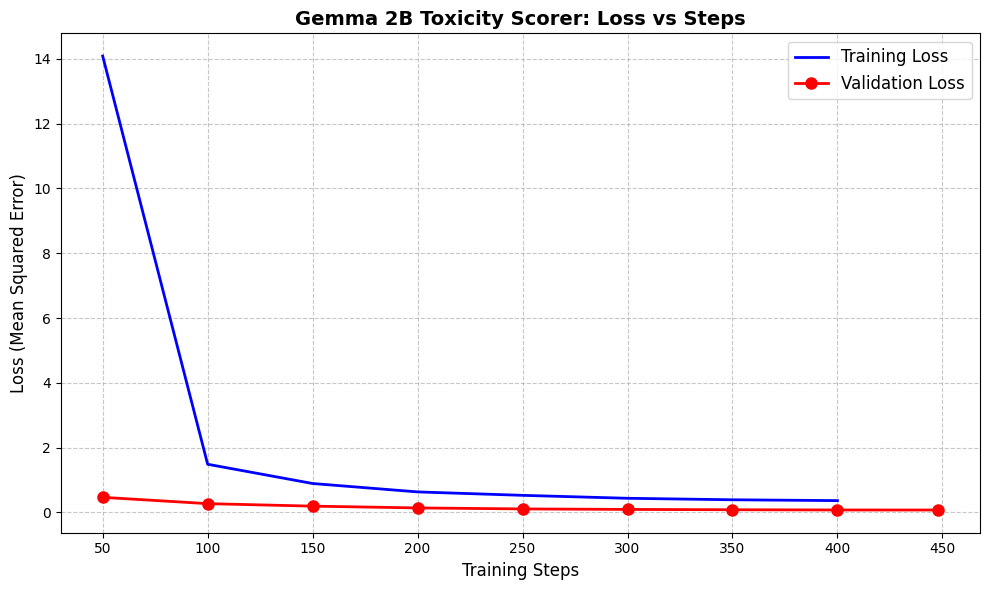

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# 1. Path to your saved training logs
# Note: If it's not in best_model, try "./gemma-toxigen-regression/run_1/trainer_state.json"
log_path = "./gemma-toxigen-regression/run_1/trainer_state.json"

if not os.path.exists(log_path):
    print(f"Error: Could not find log file at {log_path}")
    print("Try changing the path to './gemma-toxigen-regression/run_1/trainer_state.json'")
else:
    print("Found training logs! Extracting data...")

    # 2. Load the JSON data
    with open(log_path, "r") as f:
        trainer_state = json.load(f)

    log_history = trainer_state["log_history"]

    # 3. Separate the training logs and evaluation logs
    train_steps = []
    train_loss = []

    eval_steps = []
    eval_loss = []

    for log in log_history:
        # If 'loss' is in the log, it's a training step (logged every 50 steps)
        if "loss" in log and "step" in log:
            train_steps.append(log["step"])
            train_loss.append(log["loss"])

        # If 'eval_loss' is in the log, it's an evaluation step (logged at the end of the epoch)
        if "eval_loss" in log and "step" in log:
            eval_steps.append(log["step"])
            eval_loss.append(log["eval_loss"])

    # 4. Plot the data
    plt.figure(figsize=(10, 6))

    # Plot Training Loss
    if train_steps:
        plt.plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)

    # Plot Validation Loss (Usually just a dot or two for 1 epoch, so we use a scatter marker)
    if eval_steps:
        plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o', markersize=8, linewidth=2)

    # Styling the plot
    plt.title('Gemma 2B Toxicity Scorer: Loss vs Steps', fontsize=14, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    # Show the plot
    plt.tight_layout()
    plt.show()